<a href="https://colab.research.google.com/github/BhavyaKyasani/Hospital-Command-Center-Analysis/blob/main/Copy_of_Staff_Scheduling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
path = "/content/staff_scheduling_dataset_FINAL_15000.csv"

df = pd.read_csv(path)

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (15000, 10)


In [ ]:
print("First 5 Rows")
display(df.head())

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,Staff ID,Department,Shift Duration (Hours),Patient Load,Workdays per Month,Satisfaction Score,Overtime Hours,Years of Experience,Previous Satisfaction Rating,Absenteeism (Days)
0,S00000,Pediatrics,10,9,17.0,1.56,11,17,3.44,3
1,S00001,General Medicine,12,17,22.0,2.78,4,9,3.19,2
2,S00002,ER,8,21,19.0,3.50,8,10,2.00,3
3,S00003,Pediatrics,8,22,24.0,2.96,8,10,2.37,2
4,S00004,Pediatrics,8,12,21.0,2.61,9,7,4.41,4


Last 5 Rows


,Staff ID,Department,Shift Duration (Hours),Patient Load,Workdays per Month,Satisfaction Score,Overtime Hours,Years of Experience,Previous Satisfaction Rating,Absenteeism (Days)
14995,STAFF14995,ER,Night,9,NaN,3.82,2,18,NaN,0
14996,STAFF14996,ICU,Afternoon,3,NaN,4.38,2,11,NaN,1
14997,STAFF14997,ICU,Night,15,NaN,3.04,1,23,NaN,0
14998,STAFF14998,General Medicine,Night,14,NaN,4.70,0,8,NaN,0
14999,STAFF14999,ER,Morning,3,NaN,4.94,1,18,NaN,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Staff ID                      15000 non-null  object 
 1   Department                    15000 non-null  object 
 2   Shift Duration (Hours)        15000 non-null  object 
 3   Patient Load                  15000 non-null  int64  
 4   Workdays per Month            1000 non-null   float64
 5   Satisfaction Score            15000 non-null  float64
 6   Overtime Hours                15000 non-null  int64  
 7   Years of Experience           15000 non-null  int64  
 8   Previous Satisfaction Rating  1000 non-null   float64
 9   Absenteeism (Days)            15000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 1.1+ MB


In [ ]:
print(df.dtypes)

Staff ID                         object
Department                       object
Shift Duration (Hours)           object
Patient Load                      int64
Workdays per Month              float64
Satisfaction Score              float64
Overtime Hours                    int64
Years of Experience               int64
Previous Satisfaction Rating    float64
Absenteeism (Days)                int64
dtype: object


In [ ]:
display(df.describe(include='all'))

,Staff ID,Department,Shift Duration (Hours),Patient Load,Workdays per Month,Satisfaction Score,Overtime Hours,Years of Experience,Previous Satisfaction Rating,Absenteeism (Days)
count,15000,15000,15000,15000.000000,1000.000000,15000.000000,15000.000000,15000.00000,1000.000000,15000.000000
unique,15000,4,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STAFF14999,General Medicine,Afternoon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3828,4704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,8.891000,21.959000,3.932192,1.703067,15.19260,3.001440,0.319533
std,NaN,NaN,NaN,4.410761,4.332215,0.677581,2.921004,8.57913,1.161666,0.687117
min,NaN,NaN,NaN,2.000000,15.000000,1.000000,0.000000,1.00000,1.020000,0.000000
25%,NaN,NaN,NaN,5.000000,18.000000,3.450000,0.000000,8.00000,1.987500,0.000000
50%,NaN,NaN,NaN,9.000000,22.000000,3.970000,1.000000,15.00000,2.970000,0.000000
75%,NaN,NaN,NaN,12.000000,26.000000,4.480000,2.000000,23.00000,4.012500,0.000000


Missing Values:
Staff ID                            0
Department                          0
Shift Duration (Hours)              0
Patient Load                        0
Workdays per Month              14000
Satisfaction Score                  0
Overtime Hours                      0
Years of Experience                 0
Previous Satisfaction Rating    14000
Absenteeism (Days)                  0
dtype: int64


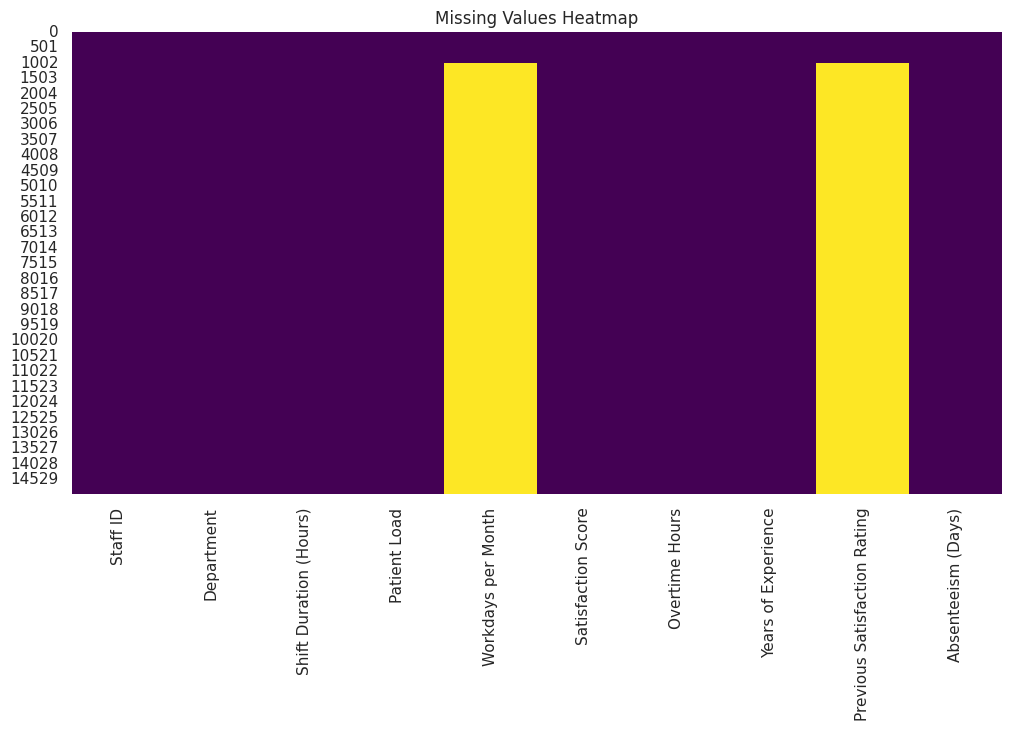

In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

display(unique)

,Column,Unique Values
0,Staff ID,15000
1,Department,4
2,Shift Duration (Hours),6
3,Patient Load,23
4,Workdays per Month,15
5,Satisfaction Score,387
6,Overtime Hours,20
7,Years of Experience,30
8,Previous Satisfaction Rating,357
9,Absenteeism (Days),5


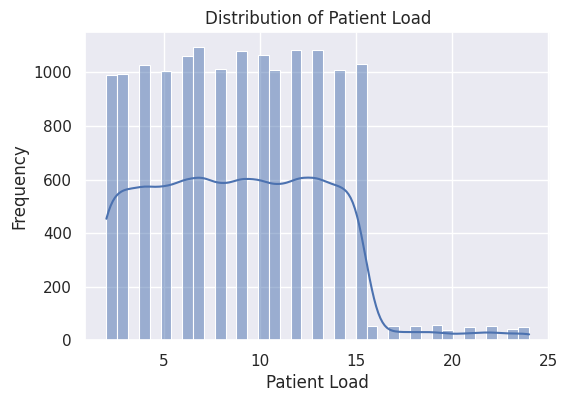

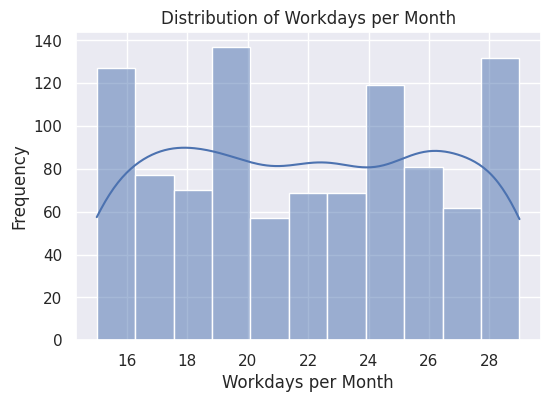

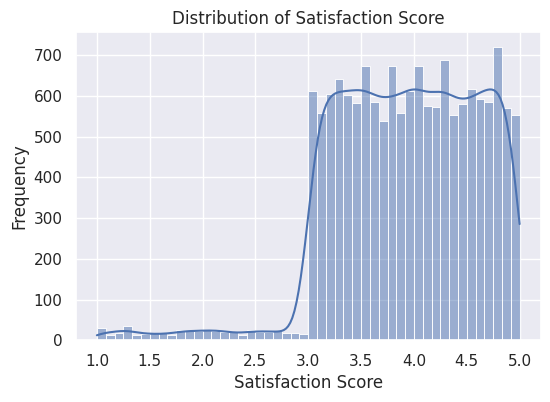

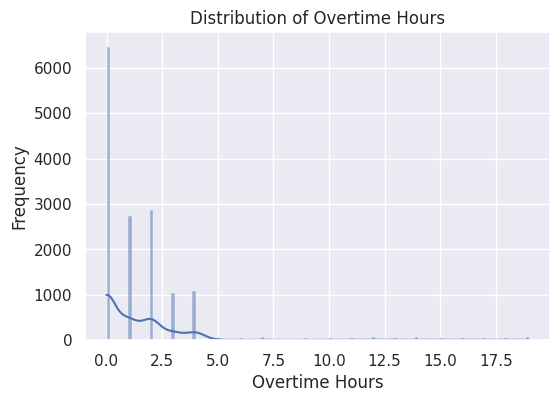

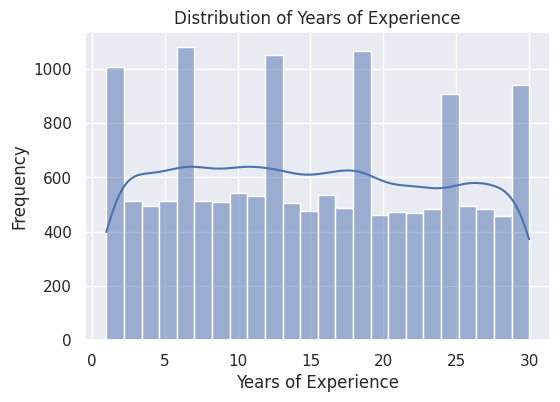

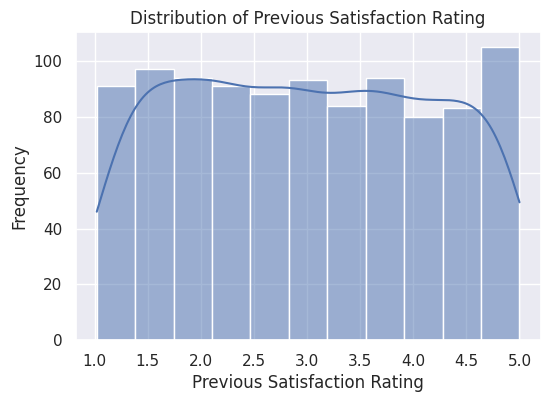

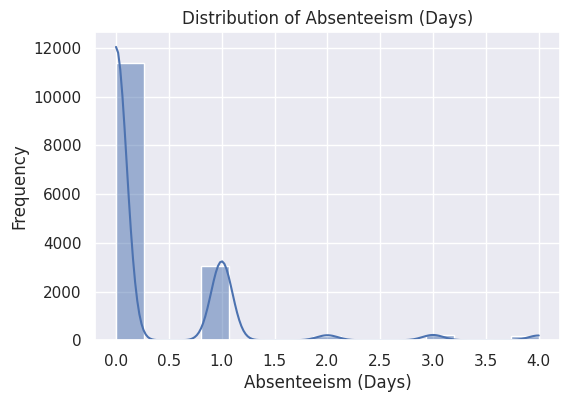

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

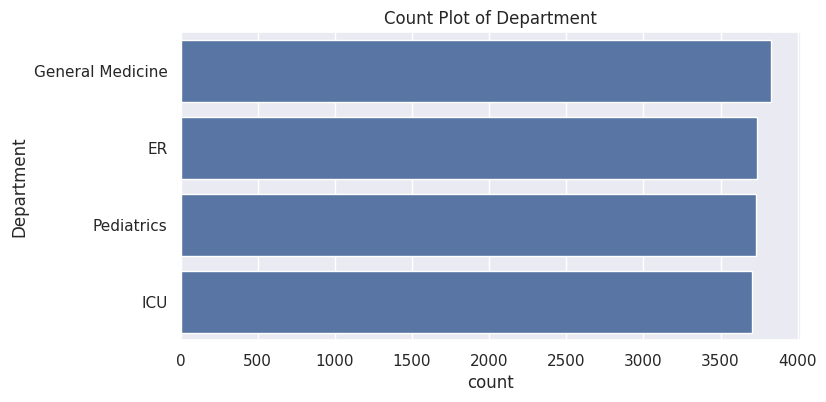

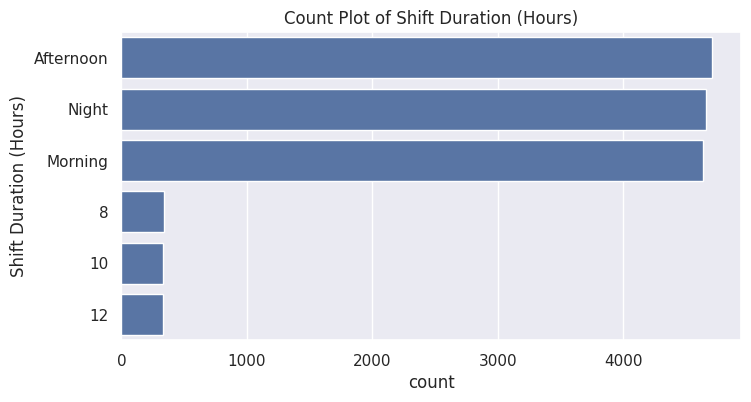

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Count Plot of {col}")
        plt.show()

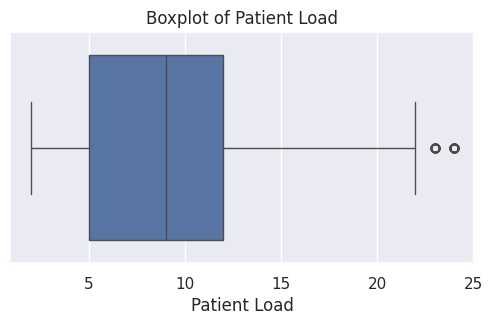

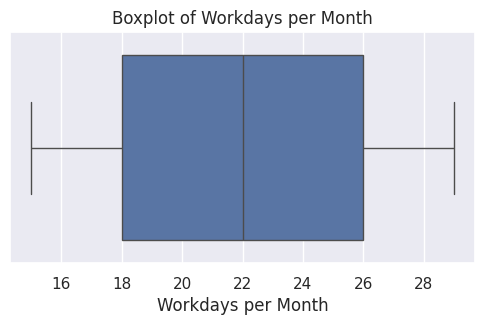

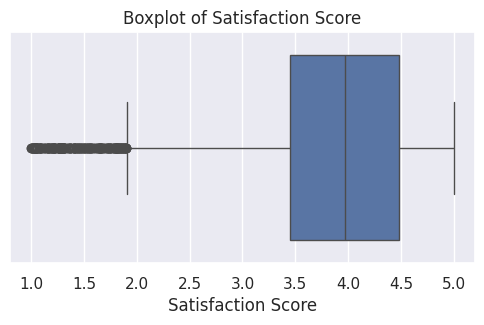

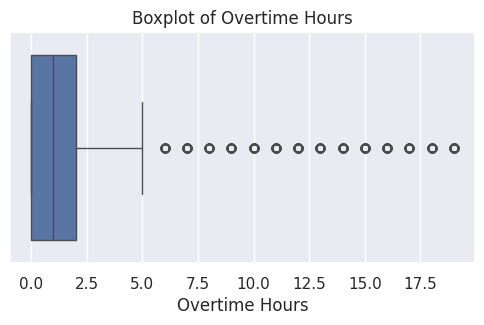

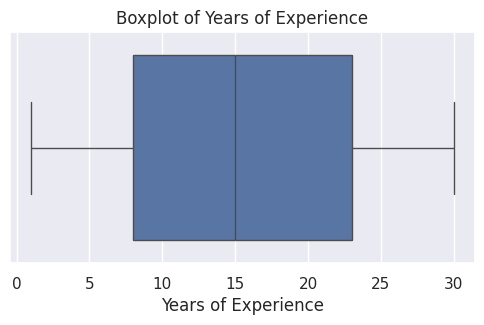

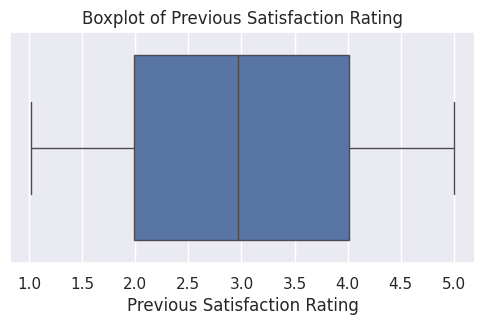

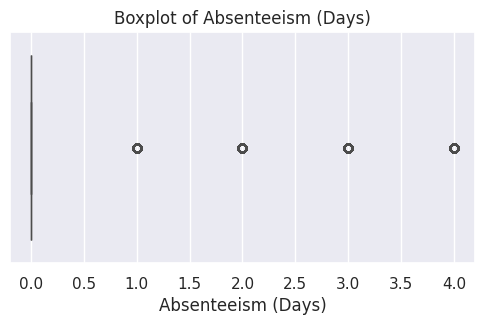

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

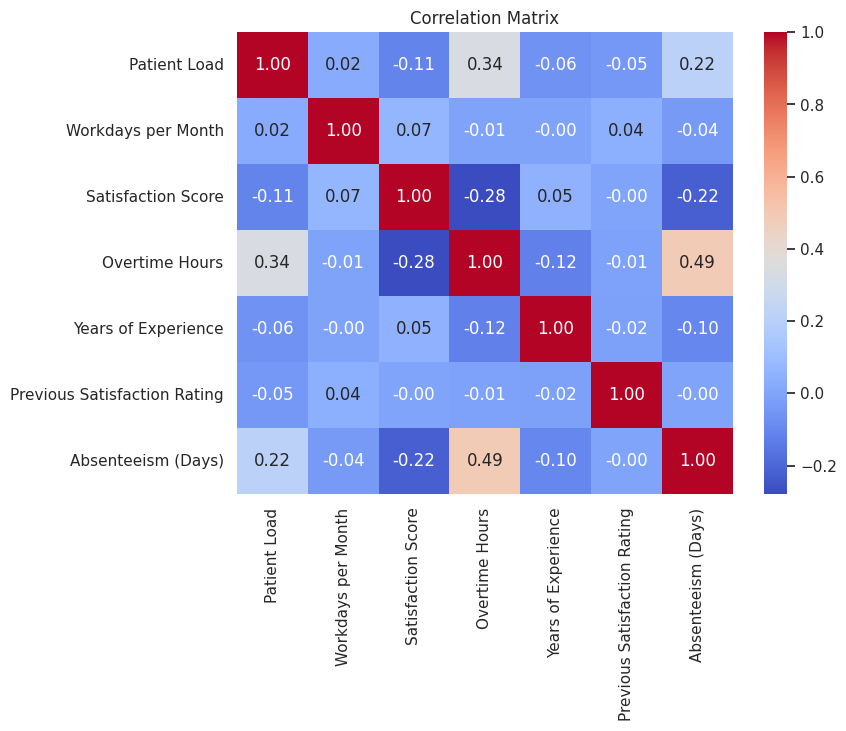

In [ ]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
clean_df = df.drop_duplicates()

clean_df.to_csv("/content/staff_scheduling_dataset_FINAL_15000_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
